## 1. Make a binary classification dataset with Scikit-Learn's make_moons() function.  

For consistency, the dataset should have 1000 samples and a random_state=42.  

Turn the data into PyTorch tensors. Split the data into training and test sets using train_test_split with 80% training and 20% testing.

In [1]:
# Device agnostic code 
import torch 

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [2]:
from sklearn.datasets import make_moons

NUM_SAMPLES = 1000
RANDOM_SEED = 42

X, y = make_moons(n_samples=NUM_SAMPLES,
                  noise=0.07,
                  random_state=RANDOM_SEED
)



In [3]:
X[:10] , y[:10]

(array([[-0.03341062,  0.4213911 ],
        [ 0.99882703, -0.4428903 ],
        [ 0.88959204, -0.32784256],
        [ 0.34195829, -0.41768975],
        [-0.83853099,  0.53237483],
        [ 0.59906425, -0.28977331],
        [ 0.29009023, -0.2046885 ],
        [-0.03826868,  0.45942924],
        [ 1.61377123, -0.2939697 ],
        [ 0.693337  ,  0.82781911]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

In [4]:
# Turn data into a DataFrame
import pandas as pd
data_df = pd.DataFrame({"X0": X[:, 0],
                        "X1": X[:, 1],
                        "y": y})
data_df.head()

,X0,X1,y
0,-0.033411,0.421391,1
1,0.998827,-0.442890,1
2,0.889592,-0.327843,1
3,0.341958,-0.417690,1
4,-0.838531,0.532375,0


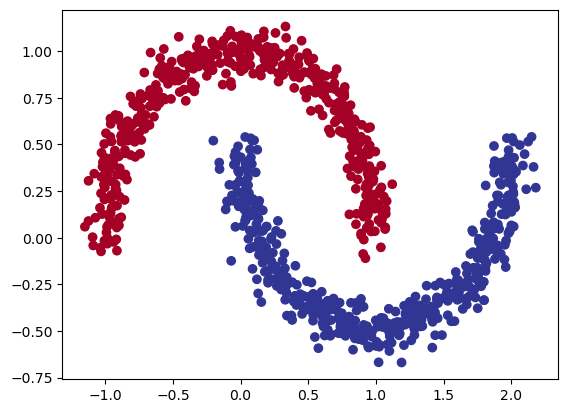

In [5]:

# Visualize the data on a plot
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [6]:
from sklearn.model_selection import train_test_split
# turn into the tensors

X = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float)

#Split the data set into train and test 

X_train ,X_test, y_train,y_test = train_test_split(X,
                                                   y,
                                                   test_size=0.2,
                                                   random_state=RANDOM_SEED

)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Build a model by subclassing nn.Module that incorporates non-linear activation functions and is capable of fitting the data you created in 1.  

Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [11]:
import torch 
from torch import nn

class MoonModelV0(nn.Module):
    def __init__(self,in_features,out_features,hidden_units):
        super().__init__()

        self.layer1 = nn.Linear(in_features=in_features,
                                out_features=hidden_units)
        self.layer2 = nn.Linear(in_features=hidden_units,
                                out_features=hidden_units)
        self.layer3 = nn.Linear(in_features=hidden_units,
                                out_features=out_features)
        
        self.relu = nn.ReLU()
        
    def forward(self,x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
    


model_0 = MoonModelV0(in_features=2,
                      out_features=1,
                      hidden_units=10)


model_0

MoonModelV0(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [12]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.3780, -0.4999],
                      [-0.1722,  0.3644],
                      [-0.1961, -0.6445],
                      [ 0.5299,  0.3180],
                      [-0.4858,  0.1110],
                      [ 0.6452,  0.3942],
                      [-0.0724, -0.4770],
                      [-0.6357,  0.0021],
                      [ 0.3949,  0.1978],
                      [-0.1935, -0.1358]])),
             ('layer1.bias',
              tensor([-0.4249,  0.0861,  0.6064, -0.5388,  0.2347,  0.0282, -0.0159, -0.3366,
                       0.2192,  0.3445])),
             ('layer2.weight',
              tensor([[-0.2179,  0.2341,  0.0254, -0.1809, -0.0733, -0.1096,  0.2413,  0.1710,
                        0.2707, -0.2741],
                      [ 0.1003,  0.1572, -0.1512,  0.0716,  0.1695, -0.2676,  0.2382,  0.1481,
                       -0.2217, -0.0097],
                      [ 0.0547,  0.2041,  0.0445, -0.0097,  0.2712,  0.2874

## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [13]:
loss_fn = nn.BCEWithLogitsLoss() # with sigmoid

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.  

* To measure model accuray, you can create your own accuracy function or use the accuracy function in TorchMetrics.
* Train the model for long enough for it to reach over 96% accuracy.
* The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [ ]:
print("Logits:")

print(model_0(X_train.to(device)[:10]).squeeze())



In [14]:
from torchmetrics import Accuracy 
acc_fn = Accuracy(task="multiclass",num_classes=2).to(device)

acc_fn


MulticlassAccuracy()

In [ ]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

X_train , y_train = X_train.to(device) , y_train.to(device)
X_test , y_test = X_test.to(device), y_test.to(device)